In [1]:
import pandas as pd

data = pd.read_csv("AmesHousing.csv")
print(data.head())
print(data.columns)

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [2]:
data.isnull().sum().sort_values(ascending=False).head(30)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
Garage Cars          1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Garage Area          1
Paved Drive          0
Full Bath            0
Half Bath            0
dtype: int64

In [3]:
col_fill_null = ['Pool QC', 'Misc Feature','Alley','Fence','Fireplace Qu','Garage Finish','Garage Qual', 'Garage Cond' ,'Garage Type', 'Bsmt Qual','Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2','Mas Vnr Type']

for col in col_fill_null:
        data[col] = data[col].fillna("None")

In [4]:
data.isnull().sum().sort_values(ascending=False).head(13)

Lot Frontage      490
Garage Yr Blt     159
Mas Vnr Area       23
Bsmt Half Bath      2
Bsmt Full Bath      2
Garage Cars         1
Garage Area         1
BsmtFin SF 1        1
Electrical          1
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Full Bath           0
dtype: int64

In [5]:
data['Lot Frontage'] = data['Lot Frontage'].fillna(data['Lot Frontage'].median())
data['Garage Yr Blt'] = data['Garage Yr Blt'].fillna(data['Garage Yr Blt'].median())
data['Mas Vnr Area'] = data['Mas Vnr Area'].fillna(0)

data = data.fillna(data.mode().iloc[0])

data.isnull().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64

In [6]:
cat_col=data.select_dtypes(include='object').columns
print(len(cat_col))

43


In [7]:
data = pd.get_dummies(data, columns=cat_col, drop_first=True)
print(data.shape)

(2930, 278)


In [8]:
data['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [9]:
corr = data.corr(numeric_only=True)
corr['SalePrice'].sort_values(ascending=False).head(10)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640138
Total Bsmt SF     0.632529
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64

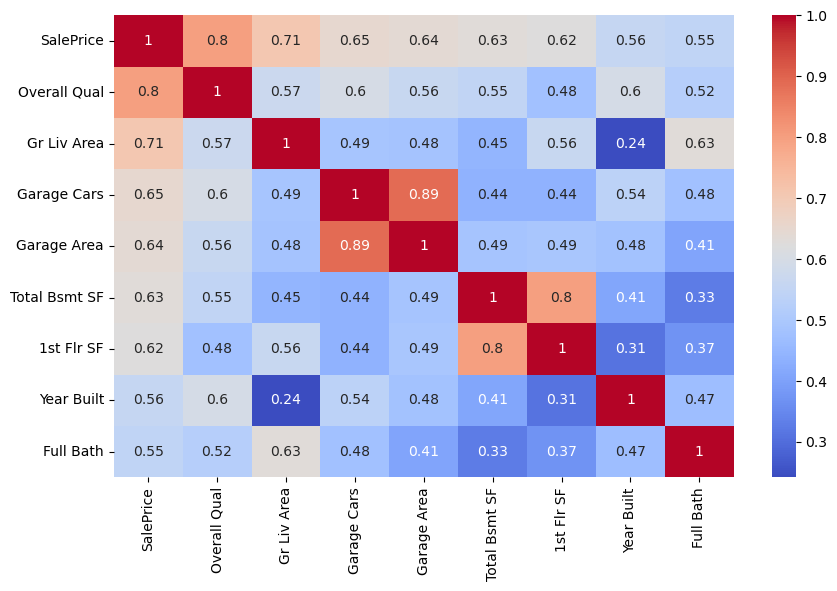

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = ['SalePrice','Overall Qual','Gr Liv Area','Garage Cars', 'Garage Area','Total Bsmt SF','1st Flr SF','Year Built','Full Bath']
corr_matrix = data[top_features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

<Axes: >

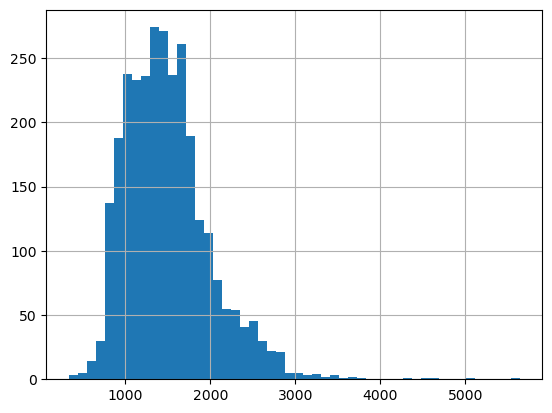

In [13]:
data = data.drop(['Garage Area','1st Flr SF'], axis =1)

import numpy as np
data['SalePrice'] = np.log1p(data['SalePrice'])
data['Gr Liv Area'].hist(bins=50)

<Axes: xlabel='SalePrice'>

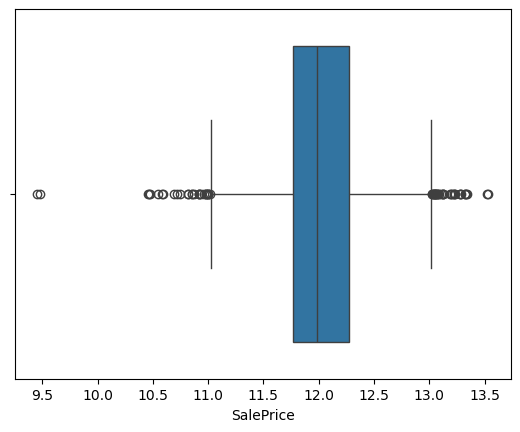

In [14]:
sns.boxplot(x=data['SalePrice'])

In [15]:
data = data[data['Gr Liv Area'] < 4000]
data = data[data['SalePrice'] < 13.5]

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

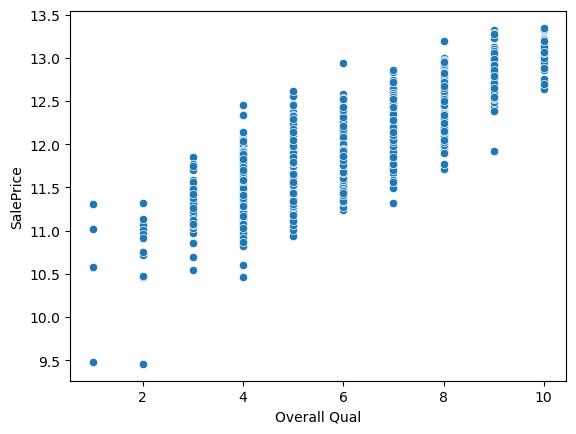

In [17]:
sns.scatterplot(x=data['Overall Qual'], y=data['SalePrice'])

<Axes: xlabel='Year Built', ylabel='SalePrice'>

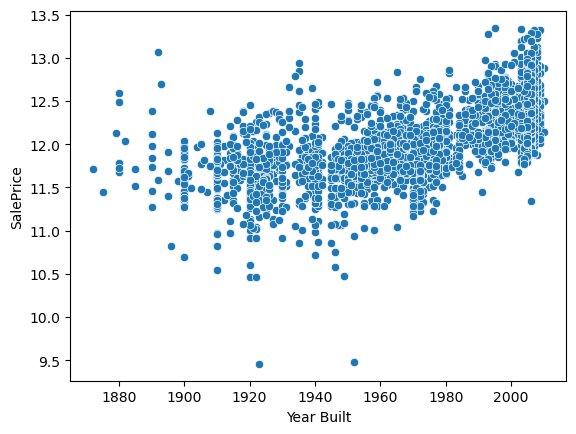

In [18]:
sns.scatterplot(x=data['Year Built'], y=data['SalePrice'])

In [19]:
data['Total SF'] = data['Total Bsmt SF'] + data['Gr Liv Area']
data['House Age'] = data['Yr Sold']-data['Year Built']

In [20]:
data.skew(numeric_only=True).sort_values(ascending=False).head(10)

Kitchen Qual_Po         54.083269
Exterior 1st_PreCast    54.083269
Roof Matl_Membran       54.083269
Utilities_NoSeWa        54.083269
Exterior 2nd_PreCast    54.083269
Roof Matl_Metal         54.083269
Roof Matl_Roll          54.083269
Condition 2_RRAn        54.083269
Condition 2_RRAe        54.083269
Exterior 2nd_Other      54.083269
dtype: float64

In [22]:
low_corr = corr['SalePrice'].abs().sort_values()
print(low_corr.head(20))

Foundation_Wood         0.000054
Roof Matl_Metal         0.000184
Sale Type_ConLI         0.000480
Condition 1_RRAn        0.001018
Condition 2_RRAe        0.002129
Sale Type_CWD           0.002763
Pool QC_TA              0.004127
House Style_2.5Unf      0.004139
Roof Matl_Tar&Grv       0.004838
BsmtFin SF 2            0.006018
Roof Style_Shed         0.006421
Alley_Pave              0.007973
Neighborhood_Greens     0.008343
Neighborhood_SawyerW    0.008653
Utilities_NoSeWa        0.010016
Roof Matl_Roll          0.010132
Sale Type_VWD           0.010132
Neighborhood_Landmrk    0.010132
Condition 2_RRAn        0.010154
Roof Style_Mansard      0.011198
Name: SalePrice, dtype: float64


In [24]:
low_features = low_corr[low_corr <0.05].index

data = data.drop(low_features, axis=1)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 

x = data.drop('SalePrice', axis=1)
y= data['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error 

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE: ", mae,"\nRMSE: ",rmse)

MAE:  0.07877783358273609 
RMSE:  0.12493148003036884


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RF RMSE:", rmse_rf)

RF RMSE: 0.12914835017444373


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RF RMSE:", rmse_rf)

RF RMSE: 0.12883033273507713
